# BioGPT Zero-Shot Experiment — Independent Comparison Group

## Experimental Positioning

This notebook implements BioGPT as a **standalone third comparison group**, separate from the main 3×2 discriminative matrix.

| Group | Paradigm | Classification Method |
|-------|----------|-----------------------|
| Main Experiment (6 pipelines) | Discriminative (supervised) | SVM / MLP trained on PubMedQA |
| Baseline | Discriminative (supervised) | TF-IDF + Logistic Regression |
| **This Notebook** | **Generative (zero-shot)** | **BioGPT logit scoring — no training** |

**Core research question:** Can a generative biomedical LLM perform competitively on a structured 3-class classification task without any supervised training?

## Key Design Decisions
- **Input:** Natural language prompt (Question + Context), max 1024 tokens, tail truncation if needed
- **Output:** Both a constrained label (logit scoring) AND free-form generated text (for case study)
- **Evaluation:** Identical metrics to main experiment (Accuracy, Macro F1, Weighted F1) + generative-specific metrics
- **Model:** `microsoft/biogpt` — pre-trained only, never seen PubMedQA labels → true zero-shot

---
## SECTION 0 — CONFIG
### Adjust all experiment parameters here before running

In [ ]:
# ============================================================
#  CONFIG — Edit this cell to adjust all experiment parameters
# ============================================================
import os
# --- Model ---
MODEL_ID        = "microsoft/biogpt"          # Zero-shot model (pre-trained only)
#MODEL_CACHE_DIR = r"E:\0000NLP_Models"         
_SHARED_CACHE = r"E:\0000NLP_Models"          # Local cache directory for model weights
MODEL_CACHE_DIR = _SHARED_CACHE if os.path.isdir(_SHARED_CACHE) else None

# --- Input ---
MAX_INPUT_TOKENS = 1024    # BioGPT max context window
TRUNCATION_SIDE  = "right" # Truncate tail of context if over limit ('right' = tail truncation)

# --- Generation (free-text output for case study) ---
MAX_NEW_TOKENS   = 30      # Max tokens to generate for free-text output
TEMPERATURE      = 1.0     # Sampling temperature (1.0 = default, lower = more deterministic)
DO_SAMPLE        = False   # False = greedy decoding (deterministic), True = sampling

# --- Label Consistency (prompt sensitivity test) ---
# Three prompt variants used to test whether label changes with rephrasing
PROMPT_VARIANTS = [
    "Question: {question}\nContext: {context}\nBased on the context, the answer is (yes/no/maybe):",
    "Based on the following biomedical context, answer yes, no, or maybe.\nQuestion: {question}\nContext: {context}\nAnswer:",
    "Context: {context}\nGiven the above, the answer to '{question}' is (yes/no/maybe):",
]

# --- Confidence Margin ---
CONFIDENCE_MARGIN_THRESHOLD = 1.0  # Samples with margin below this are flagged as 'uncertain'

# --- Error Analysis Display ---
TOP_K_ERROR_CASES        = 20      # Number of error cases to display in error analysis
SHOW_LOW_CONFIDENCE_ONLY = False   # True = filter display to only uncertain samples
LENGTH_BUCKET_THRESHOLD  = 512     # Token length above which a sample is considered 'long'

# --- Data ---
DATASET_NAME   = "qiaojin/PubMedQA"
DATASET_CONFIG = "pqa_labeled"
DATASET_SPLIT  = "train"           # PubMedQA labeled set
TEST_SIZE      = 500               # Number of samples to evaluate (set None to use all)
RANDOM_SEED    = 11

# ============================================================
print("Config loaded.")
print(f"  Model        : {MODEL_ID}")
#print(f"  Cache dir    : {MODEL_CACHE_DIR}")
if MODEL_CACHE_DIR:
    print(f"Using shared cache directory: {MODEL_CACHE_DIR}")
else:
    print("Shared cache not found, using HuggingFace default cache.")
print(f"  Max tokens   : {MAX_INPUT_TOKENS}")
print(f"  Margin thresh: {CONFIDENCE_MARGIN_THRESHOLD}")
print(f"  Test samples : {TEST_SIZE}")

Config loaded.
  Model        : microsoft/biogpt
Using shared cache directory: E:\0000NLP_Models
  Max tokens   : 1024
  Margin thresh: 1.0
  Test samples : 500


: 

---
## SECTION 1 — Setup & Imports

In [ ]:
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from transformers import BioGptTokenizer, BioGptForCausalLM
from datasets import load_dataset
from pubmed_loader import PubMedQAData

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

---
## SECTION 2 — Model Loading

> **First run:** downloads ~1.56 GB to `MODEL_CACHE_DIR`. Subsequent runs load from cache instantly.
> 
> The commented block below is for my **teammate Lingshi** running the fine-tuned version.

In [ ]:
# ============================================================
#  ZERO-SHOT MODEL — Run this block (default)
#  Model: microsoft/biogpt (pre-trained only, never seen PubMedQA labels)
# ============================================================
print(f"Loading tokenizer and model from '{MODEL_ID}' ...")
print(f"Cache directory: {MODEL_CACHE_DIR}")

tokenizer = BioGptTokenizer.from_pretrained(
    MODEL_ID,
    cache_dir=MODEL_CACHE_DIR
)
model = BioGptForCausalLM.from_pretrained(
    MODEL_ID,
    cache_dir=MODEL_CACHE_DIR
)
model.to(DEVICE)
model.eval()
print("Zero-shot model loaded successfully.")


# ============================================================
#  FINE-TUNED MODEL — For teammate only
#  Uncomment the block below and COMMENT OUT the block above.
#  Model: BioGPT fine-tuned on PubMedQA (supervised generative)
#  Download from: https://msramllasc.blob.core.windows.net/modelrelease/BioGPT/checkpoints/BioGPT-QA-PubMedQA-BioGPT.tgz
#  After downloading, extract and set FINETUNED_MODEL_PATH to the folder path.
# ============================================================
# FINETUNED_MODEL_PATH = r"E:\0000NLP_Models\BioGPT-QA-PubMedQA-BioGPT"
#
# tokenizer = BioGptTokenizer.from_pretrained(FINETUNED_MODEL_PATH)
# model = BioGptForCausalLM.from_pretrained(FINETUNED_MODEL_PATH)
# model.to(DEVICE)
# model.eval()
# print("Fine-tuned model loaded successfully.")
# ============================================================

Loading tokenizer and model from 'microsoft/biogpt' ...
Cache directory: E:\0000NLP_Models


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie biogpt.embed_tokens.weight to output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Zero-shot model loaded successfully.


In [ ]:
# Extract token IDs for the three candidate labels
LABEL_TOKEN_IDS = {
    "yes":   tokenizer.encode("yes",   add_special_tokens=False)[0],
    "no":    tokenizer.encode("no",    add_special_tokens=False)[0],
    "maybe": tokenizer.encode("maybe", add_special_tokens=False)[0],
}
print("Label token IDs:", LABEL_TOKEN_IDS)

Label token IDs: {'yes': 22700, 'no': 102, 'maybe': 22731}


In [ ]:
# ============================================================
#  Baseline logit estimation — empty prompt
# ============================================================
LABELS = ["yes", "no", "maybe"]  # add this line

EMPTY_PROMPTS = {
    "empty_string":  "",
    "format_only":   "Answer (yes/no/maybe):",
    "question_only": "Question:\nAnswer (yes/no/maybe):",
}

print("Baseline logits from empty/content-free prompts:\n")
print(f"{'Prompt':<20} {'yes':>8} {'no':>8} {'maybe':>8}   {'argmax':>8}")
print("-" * 60)

baseline_results = {}

for name, prompt in EMPTY_PROMPTS.items():
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=True,
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**inputs).logits[0, -1, :]

    scores = {label: logits[LABEL_TOKEN_IDS[label]].item() for label in LABELS}
    best   = max(scores, key=scores.get)
    baseline_results[name] = scores

    print(f"{name:<20} {scores['yes']:>8.4f} {scores['no']:>8.4f} "
          f"{scores['maybe']:>8.4f}   {best:>8}")

Baseline logits from empty/content-free prompts:

Prompt                    yes       no    maybe     argmax
------------------------------------------------------------
empty_string          -3.4806   1.7393  -1.7883         no
format_only            4.3306   4.2038   0.8841        yes
question_only          4.4709   4.4010   2.4929        yes


---
## SECTION 3 — Data Loading

In [ ]:
dataset = PubMedQAData("data").test_set
print(f"Total samples in dataset: {len(dataset)}")
'''
dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split=DATASET_SPLIT)
print(f"Total samples in dataset: {len(dataset)}")

# Subsample if TEST_SIZE is set
if TEST_SIZE is not None and TEST_SIZE < len(dataset):
    import random
    random.seed(RANDOM_SEED)
    indices = random.sample(range(len(dataset)), TEST_SIZE)
    dataset = dataset.select(indices)
    print(f"Subsampled to {TEST_SIZE} samples (seed={RANDOM_SEED})")
'''
dataset = [{"id": doc_id, **sample} for doc_id, sample in dataset.items()]
print(f"Total samples in dataset: {len(dataset)}")
print("\nExample:")
print(f"  Question : {dataset[0]['QUESTION'][:100]}...")
print(f"  Label    : {dataset[0]['final_decision']}")

Total samples in dataset: 500
Total samples in dataset: 500

Example:
  Question : Is anorectal endosonography valuable in dyschesia?...
  Label    : yes


---
## SECTION 4 — EDA: Token Length Distribution

Verifies that prompt lengths are within the 1024-token limit.

Counting token lengths:   0%|          | 0/500 [00:00<?, ?it/s]

Counting token lengths: 100%|██████████| 500/500 [00:01<00:00, 313.78it/s]


Prompt token length statistics:
  Mean   : 298.5
  Median : 296.0
  Max    : 573
  Min    : 97
  > 1024 tokens : 0 samples (0.0%)


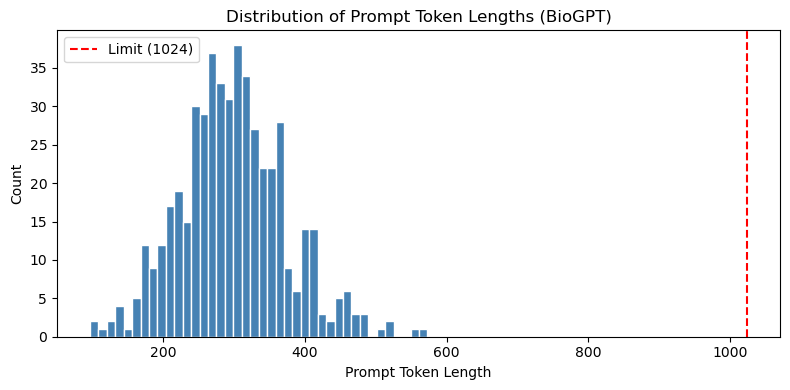

In [ ]:
def build_prompt(question, context, variant_idx=0):
    """Build prompt string using the selected variant from PROMPT_VARIANTS."""
    # Join context list to string if needed
    if isinstance(context, list):
        context = " ".join(context)
    template = PROMPT_VARIANTS[variant_idx]
    return template.format(question=question, context=context)


# Count prompt token lengths (variant 0 = primary prompt)
prompt_lengths = []
for sample in tqdm(dataset, desc="Counting token lengths"):
    prompt = build_prompt(sample["QUESTION"], sample["CONTEXTS"])
    token_len = len(tokenizer.encode(prompt))
    prompt_lengths.append(token_len)

prompt_lengths = np.array(prompt_lengths)

print(f"Prompt token length statistics:")
print(f"  Mean   : {prompt_lengths.mean():.1f}")
print(f"  Median : {np.median(prompt_lengths):.1f}")
print(f"  Max    : {prompt_lengths.max()}")
print(f"  Min    : {prompt_lengths.min()}")
print(f"  > {MAX_INPUT_TOKENS} tokens : {(prompt_lengths > MAX_INPUT_TOKENS).sum()} samples "
      f"({(prompt_lengths > MAX_INPUT_TOKENS).mean()*100:.1f}%)")

# Plot distribution
plt.figure(figsize=(8, 4))
plt.hist(prompt_lengths, bins=40, color="steelblue", edgecolor="white")
plt.axvline(MAX_INPUT_TOKENS, color="red", linestyle="--", label=f"Limit ({MAX_INPUT_TOKENS})")
plt.xlabel("Prompt Token Length")
plt.ylabel("Count")
plt.title("Distribution of Prompt Token Lengths (BioGPT)")
plt.legend()
plt.tight_layout()
plt.show()

---
## SECTION 5 — Core Inference Functions

In [ ]:
def predict_single(question, context, variant_idx=0):
    """
    Run a single inference on one sample.
    Returns:
        predicted_label   : str  — 'yes', 'no', or 'maybe' (from logit scoring)
        confidence_scores : dict — raw logit values for all three labels
        confidence_margin : float — score(best) - score(second_best)
        generated_text    : str  — free-form generated continuation (for case study)
    """
    prompt = build_prompt(question, context, variant_idx)

    # Tokenize with tail truncation
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_TOKENS,
        padding=False,
    ).to(DEVICE)

    with torch.no_grad():
        # --- Logit scoring (constrained label) ---
        logit_outputs = model(**inputs)
        next_token_logits = logit_outputs.logits[0, -1, :]  # last position

        scores = {
            label: next_token_logits[tid].item()
            for label, tid in LABEL_TOKEN_IDS.items()
        }
        sorted_scores = sorted(scores.values(), reverse=True)
        predicted_label   = max(scores, key=scores.get)
        confidence_margin = sorted_scores[0] - sorted_scores[1]

        # --- Free-text generation ---
        gen_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=TEMPERATURE if DO_SAMPLE else None,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    # Decode only the newly generated tokens
    input_len      = inputs["input_ids"].shape[1]
    generated_ids  = gen_ids[0][input_len:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    return {
        "predicted_label":   predicted_label,
        "confidence_scores": {k: round(v, 4) for k, v in scores.items()},
        "confidence_margin": round(confidence_margin, 4),
        "generated_text":    generated_text,
    }

In [ ]:
# Quick sanity check on one sample
sample = dataset[0]
result = predict_single(sample["QUESTION"], sample["CONTEXTS"])

print("=== Sanity Check ===")
print(f"Question       : {sample['QUESTION'][:120]}...")
print(f"True label     : {sample['final_decision']}")
print(f"Predicted label: {result['predicted_label']}")
print(f"Logit scores   : {result['confidence_scores']}")
print(f"Margin         : {result['confidence_margin']}")
print(f"Generated text : {result['generated_text']}")

=== Sanity Check ===
Question       : Is anorectal endosonography valuable in dyschesia?...
True label     : yes
Predicted label: no
Logit scores   : {'yes': 1.5652, 'no': 4.9266, 'maybe': 2.3918}
Margin         : 2.5348
Generated text : The anal sphincter and the m.


---
## SECTION 6 — Batch Inference

In [ ]:
records = []

for i, sample in enumerate(tqdm(dataset, desc="Running BioGPT inference")):
    question = sample["QUESTION"]
    context  = sample["CONTEXTS"]
    true_label = sample["final_decision"].lower().strip()

    result = predict_single(question, context, variant_idx=0)

    # Token length of this sample's prompt
    prompt     = build_prompt(question, context)
    token_len  = len(tokenizer.encode(prompt))
    truncated  = token_len >= MAX_INPUT_TOKENS

    records.append({
        "idx":               i,
        "question":          question,
        "true_label":        true_label,
        "predicted_label":   result["predicted_label"],
        "correct":           result["predicted_label"] == true_label,
        "score_yes":         result["confidence_scores"]["yes"],
        "score_no":          result["confidence_scores"]["no"],
        "score_maybe":       result["confidence_scores"]["maybe"],
        "confidence_margin": result["confidence_margin"],
        "generated_text":    result["generated_text"],
        "prompt_token_len":  token_len,
        "truncated":         truncated,
    })

df = pd.DataFrame(records)
print(f"Inference complete. Total samples: {len(df)}")
df.head(3)

Running BioGPT inference: 100%|██████████| 500/500 [03:43<00:00,  2.23it/s]

Inference complete. Total samples: 500


,idx,question,true_label,predicted_label,correct,score_yes,score_no,score_maybe,confidence_margin,generated_text,prompt_token_len,truncated
0,0,Is anorectal endosonography valuable in dysche...,yes,no,False,1.5652,4.9266,2.3918,2.5348,The anal sphincter and the m.,284,False
1,1,Is there a connection between sublingual varic...,yes,no,False,3.6714,6.0650,2.1481,2.3936,The results of this study suggest that subling...,345,False
2,2,Is the affinity column-mediated immunoassay me...,yes,no,False,1.0176,4.5347,1.3418,3.1929,The ACMIA method is a useful alternative to th...,285,False


---
## SECTION 7 — Standard Evaluation Metrics

Identical to main experiment metrics for direct comparison.

In [ ]:
y_true = df["true_label"].tolist()
y_pred = df["predicted_label"].tolist()
labels = ["yes", "no", "maybe"]

accuracy    = accuracy_score(y_true, y_pred)
macro_f1    = f1_score(y_true, y_pred, average="macro",    labels=labels, zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0)

print("=" * 45)
print(" BioGPT Zero-Shot — Evaluation Results")
print("=" * 45)
print(f"  Accuracy     : {accuracy:.4f}")
print(f"  Macro F1     : {macro_f1:.4f}")
print(f"  Weighted F1  : {weighted_f1:.4f}")
print("\nPer-class Report:")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

 BioGPT Zero-Shot — Evaluation Results
  Accuracy     : 0.3600
  Macro F1     : 0.2087
  Weighted F1  : 0.2372

Per-class Report:
              precision    recall  f1-score   support

         yes       0.69      0.07      0.12       276
          no       0.34      0.96      0.51       169
       maybe       0.00      0.00      0.00        55

    accuracy                           0.36       500
   macro avg       0.35      0.34      0.21       500
weighted avg       0.50      0.36      0.24       500



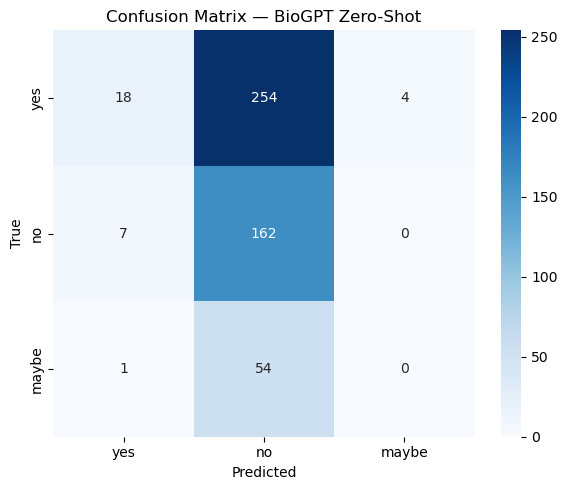

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — BioGPT Zero-Shot")
plt.tight_layout()
plt.show()

---
## SECTION 8 — Generative-Specific Metrics

### Thresholds and parameters are controlled in the CONFIG cell (Section 0)

Three metrics unique to generative models:
1. **Confidence Margin** — How decisive was the model? Low margin = uncertain prediction
2. **Label Consistency** — Does the label change when the prompt is rephrased?
3. **Output Parsability** — Does the free-form generated text contain a valid keyword?

Confidence Margin Threshold : 1.0
Uncertain samples           : 91 (18.2%)
Accuracy on uncertain       : 0.3297
Accuracy on confident       : 0.3667


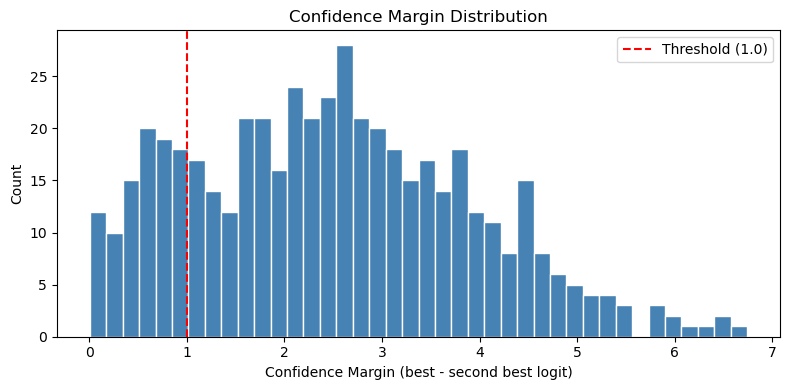

In [ ]:
# -------------------------------------------------------
# Metric 1: Confidence Margin
# -------------------------------------------------------
df["uncertain"] = df["confidence_margin"] < CONFIDENCE_MARGIN_THRESHOLD

uncertain_count  = df["uncertain"].sum()
uncertain_pct    = df["uncertain"].mean() * 100
uncertain_acc    = df[df["uncertain"]]["correct"].mean()
confident_acc    = df[~df["uncertain"]]["correct"].mean()

print(f"Confidence Margin Threshold : {CONFIDENCE_MARGIN_THRESHOLD}")
print(f"Uncertain samples           : {uncertain_count} ({uncertain_pct:.1f}%)")
print(f"Accuracy on uncertain       : {uncertain_acc:.4f}")
print(f"Accuracy on confident       : {confident_acc:.4f}")

# Distribution plot
plt.figure(figsize=(8, 4))
plt.hist(df["confidence_margin"], bins=40, color="steelblue", edgecolor="white")
plt.axvline(CONFIDENCE_MARGIN_THRESHOLD, color="red", linestyle="--",
            label=f"Threshold ({CONFIDENCE_MARGIN_THRESHOLD})")
plt.xlabel("Confidence Margin (best - second best logit)")
plt.ylabel("Count")
plt.title("Confidence Margin Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------
# Metric 2: Label Consistency
# Tests whether predicted label changes across PROMPT_VARIANTS
# -------------------------------------------------------
print(f"Running label consistency test across {len(PROMPT_VARIANTS)} prompt variants...")
print("This may take a while.")

consistency_records = []

for i, sample in enumerate(tqdm(dataset, desc="Consistency check")):
    labels_per_variant = []
    for v_idx in range(len(PROMPT_VARIANTS)):
        result = predict_single(sample["QUESTION"], sample["CONTEXTS"], variant_idx=v_idx)
        labels_per_variant.append(result["predicted_label"])
    
    is_consistent = len(set(labels_per_variant)) == 1
    consistency_records.append({
        "idx":            i,
        "true_label":     sample["final_decision"].lower().strip(),
        "labels":         labels_per_variant,
        "is_consistent":  is_consistent,
    })

df_consistency = pd.DataFrame(consistency_records)
consistency_rate = df_consistency["is_consistent"].mean() * 100

print(f"\nLabel Consistency Rate: {consistency_rate:.1f}%")
print(f"  ({df_consistency['is_consistent'].sum()}/{len(df_consistency)} samples "
      f"produced the same label across all {len(PROMPT_VARIANTS)} prompt variants)")

# Show inconsistent samples
df_inconsistent = df_consistency[~df_consistency["is_consistent"]]
print(f"\nInconsistent samples ({len(df_inconsistent)}):")
df_inconsistent.head(10)

Running label consistency test across 3 prompt variants...
This may take a while.


Consistency check: 100%|██████████| 500/500 [19:57<00:00,  2.40s/it]


Label Consistency Rate: 52.8%
  (264/500 samples produced the same label across all 3 prompt variants)

Inconsistent samples (236):


,idx,true_label,labels,is_consistent
0,0,yes,"[no, yes, no]",False
1,1,yes,"[no, no, yes]",False
4,4,yes,"[no, yes, yes]",False
6,6,yes,"[no, no, yes]",False
7,7,yes,"[no, yes, yes]",False
8,8,yes,"[no, yes, no]",False
9,9,yes,"[no, no, yes]",False
10,10,yes,"[no, yes, no]",False
12,12,yes,"[no, yes, yes]",False
15,15,yes,"[no, yes, yes]",False


In [ ]:
# -------------------------------------------------------
# Metric 3: Output Parsability
# Checks whether the free-form generated text contains a valid keyword
# -------------------------------------------------------
def check_parsability(text):
    t = text.lower().strip()
    if t.startswith("yes"):   return "yes"
    if t.startswith("no"):    return "no"
    if t.startswith("maybe"): return "maybe"
    # Fallback: search anywhere in first 20 chars
    snippet = t[:20]
    for kw in ["yes", "no", "maybe"]:
        if kw in snippet:
            return kw
    return "unparsable"

df["parsed_from_text"] = df["generated_text"].apply(check_parsability)
df["is_parsable"]      = df["parsed_from_text"] != "unparsable"
df["text_label_match"] = df["parsed_from_text"] == df["predicted_label"]

parsability_rate   = df["is_parsable"].mean() * 100
text_match_rate    = df[df["is_parsable"]]["text_label_match"].mean() * 100

print(f"Output Parsability Rate          : {parsability_rate:.1f}%")
print(f"Text-label agreement (parsable)  : {text_match_rate:.1f}%")
print(f"  (agreement = free-text keyword matches logit-scored label)")

# Breakdown
print("\nParsed keyword distribution from free-text:")
print(df["parsed_from_text"].value_counts())

Output Parsability Rate          : 4.0%
Text-label agreement (parsable)  : 100.0%
  (agreement = free-text keyword matches logit-scored label)

Parsed keyword distribution from free-text:
parsed_from_text
unparsable    480
no             20
Name: count, dtype: int64


---
## SECTION 9 — Error Analysis

Three analysis dimensions:
1. Error rate **by true label** — which class is hardest?
2. Error rate **by confidence margin** — do uncertain predictions fail more?
3. Error rate **by context length** — do truncated/long samples fail more?

Error rate by true label:
true_label  total  correct  accuracy  error_rate
     maybe     55        0  0.000000    1.000000
        no    169      162  0.958580    0.041420
       yes    276       18  0.065217    0.934783


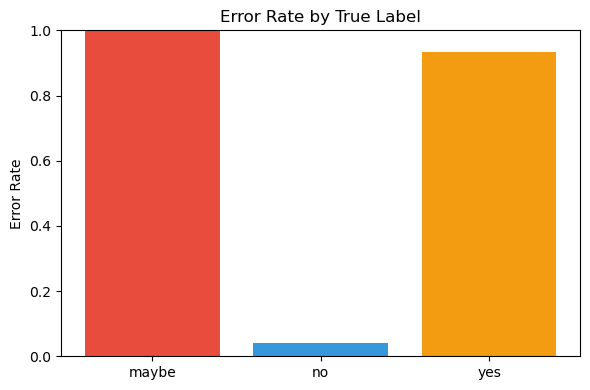

In [ ]:
# -------------------------------------------------------
# Dimension 1: Error rate by true label
# -------------------------------------------------------
label_analysis = df.groupby("true_label").agg(
    total=("correct", "count"),
    correct=("correct", "sum"),
    accuracy=("correct", "mean"),
).reset_index()
label_analysis["error_rate"] = 1 - label_analysis["accuracy"]

print("Error rate by true label:")
print(label_analysis.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(label_analysis["true_label"], label_analysis["error_rate"],
        color=["#e74c3c", "#3498db", "#f39c12"])
plt.ylabel("Error Rate")
plt.title("Error Rate by True Label")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------
# Dimension 2: Error rate by confidence margin bucket
# -------------------------------------------------------
df["margin_bucket"] = pd.cut(
    df["confidence_margin"],
    bins=[float("-inf"), 1, 2, 5, float("inf")],
    labels=["< 1 (uncertain)", "1–2", "2–5", "> 5 (confident)"]
)

margin_analysis = df.groupby("margin_bucket", observed=True).agg(
    total=("correct", "count"),
    accuracy=("correct", "mean"),
).reset_index()
margin_analysis["error_rate"] = 1 - margin_analysis["accuracy"]

print("Error rate by confidence margin bucket:")
print(margin_analysis.to_string(index=False))

Error rate by confidence margin bucket:
  margin_bucket  total  accuracy  error_rate
< 1 (uncertain)     91  0.329670    0.670330
            1–2    101  0.346535    0.653465
            2–5    285  0.371930    0.628070
> 5 (confident)     23  0.391304    0.608696


In [ ]:
# -------------------------------------------------------
# Dimension 3: Error rate by context length
# -------------------------------------------------------
df["length_bucket"] = df["prompt_token_len"].apply(
    lambda x: f"> {LENGTH_BUCKET_THRESHOLD} (long)" if x > LENGTH_BUCKET_THRESHOLD
    else f"<= {LENGTH_BUCKET_THRESHOLD} (normal)"
)

length_analysis = df.groupby("length_bucket").agg(
    total=("correct", "count"),
    accuracy=("correct", "mean"),
).reset_index()
length_analysis["error_rate"] = 1 - length_analysis["accuracy"]

print("Error rate by prompt token length:")
print(length_analysis.to_string(index=False))

Error rate by prompt token length:
  length_bucket  total  accuracy  error_rate
<= 512 (normal)    496  0.358871    0.641129
   > 512 (long)      4  0.500000    0.500000


In [ ]:
# -------------------------------------------------------
# Qualitative case study: Browse error cases
# Toggle SHOW_LOW_CONFIDENCE_ONLY in CONFIG to filter
# -------------------------------------------------------
error_df = df[df["correct"] == False].copy()

if SHOW_LOW_CONFIDENCE_ONLY:
    error_df = error_df[error_df["uncertain"] == True]
    print(f"Showing low-confidence errors only (margin < {CONFIDENCE_MARGIN_THRESHOLD})")

error_df = error_df.sort_values("confidence_margin").head(TOP_K_ERROR_CASES)

print(f"Displaying top {len(error_df)} error cases (sorted by ascending margin):\n")

for _, row in error_df.iterrows():
    print(f"[{row['idx']}] True: {row['true_label']}  Pred: {row['predicted_label']}  "
          f"Margin: {row['confidence_margin']:.3f}")
    print(f"  Scores      : yes={row['score_yes']:.2f}  no={row['score_no']:.2f}  "
          f"maybe={row['score_maybe']:.2f}")
    print(f"  Generated   : {row['generated_text'][:120]}")
    print(f"  Question    : {row['question'][:100]}...")
    print()

Displaying top 20 error cases (sorted by ascending margin):

[398] True: no  Pred: yes  Margin: 0.005
  Scores      : yes=6.43  no=6.42  maybe=3.39
  Generated   : The results of this study do not support the hypothesis that FA protects against congenital heart defects in DS.
  Question    : Can folic acid protect against congenital heart defects in Down syndrome?...

[287] True: no  Pred: yes  Margin: 0.028
  Scores      : yes=3.91  no=3.88  maybe=1.61
  Generated   : The results of this study suggest that the 2 sources of data may not agree on the number of collisions and convictions t
  Question    : Department of Transportation vs self-reported data on motor vehicle collisions and driving convictio...

[474] True: maybe  Pred: no  Margin: 0.048
  Scores      : yes=5.03  no=5.08  maybe=0.52
  Generated   : The results of this study suggest that low-income individuals in Canada are not receiving adequate assistance to receive
  Question    : Does government assistance improve utiliza

---
## SECTION 10 — Results Summary

Final consolidated summary for comparison with main experiment.

In [ ]:
print("=" * 55)
print(" FINAL SUMMARY — BioGPT Zero-Shot Experiment")
print("=" * 55)

print("\n[Standard Metrics]")
print(f"  Accuracy             : {accuracy:.4f}")
print(f"  Macro F1             : {macro_f1:.4f}")
print(f"  Weighted F1          : {weighted_f1:.4f}")

print("\n[Generative-Specific Metrics]")
print(f"  Confidence Margin    : mean={df['confidence_margin'].mean():.3f}  "
      f"median={df['confidence_margin'].median():.3f}")
print(f"  Uncertain samples    : {uncertain_count}/{len(df)} ({uncertain_pct:.1f}%) "
      f"[threshold={CONFIDENCE_MARGIN_THRESHOLD}]")
print(f"  Label Consistency    : {consistency_rate:.1f}% across {len(PROMPT_VARIANTS)} prompt variants")
print(f"  Output Parsability   : {parsability_rate:.1f}% of generated texts contain valid keyword")
print(f"  Text-Label Agreement : {text_match_rate:.1f}% (where parsable)")

print("\n[Data]")
print(f"  Total samples        : {len(df)}")
print(f"  Truncated samples    : {df['truncated'].sum()} ({df['truncated'].mean()*100:.1f}%)")
print(f"  Model                : {MODEL_ID}")
print(f"  Paradigm             : Generative / Zero-Shot")

# Export results to CSV for cross-experiment comparison
output_path = "biogpt_results_prompt_v0_optimized.csv.csv"
df.to_csv(output_path, index=False)
print(f"\nResults saved to: {output_path}")

 FINAL SUMMARY — BioGPT Zero-Shot Experiment

[Standard Metrics]
  Accuracy             : 0.3600
  Macro F1             : 0.2087
  Weighted F1          : 0.2372

[Generative-Specific Metrics]
  Confidence Margin    : mean=2.485  median=2.421
  Uncertain samples    : 91/500 (18.2%) [threshold=1.0]
  Label Consistency    : 52.8% across 3 prompt variants
  Output Parsability   : 4.0% of generated texts contain valid keyword
  Text-Label Agreement : 100.0% (where parsable)

[Data]
  Total samples        : 500
  Truncated samples    : 0 (0.0%)
  Model                : microsoft/biogpt
  Paradigm             : Generative / Zero-Shot

Results saved to: biogpt_results.csv
